# Project 2 :- Customer Segmentation and Profiling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("marketing_campaign.csv",sep="\t")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df["Income"] = df["Income"].fillna(df["Income"].median())  # median outliers se affect nhi hoti

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

# Feature engineering :-

In [11]:
# Customer ne total kitna spend kiya

df["Total_Spending"] = ( df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] 
                         + df["MntSweetProducts"] + df["MntGoldProds"])

In [12]:
# Total purchases

df["Total_Purchases"] = (df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"])

In [13]:
# dataset me bith year hai... usse apn jldi ye pta nhi lga skte ki customer ki age kitni hai..  

df["Age"] = 2026 - df["Year_Birth"]

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Total_Purchases,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,1617,22,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,27,4,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,776,20,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,53,6,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,422,14,45


# EDA

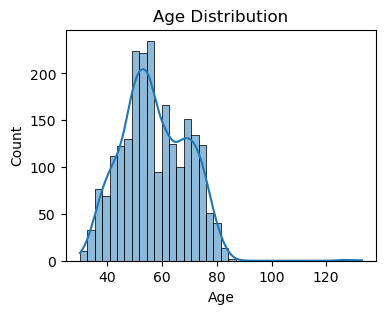

In [15]:
plt.figure(figsize=(4,3))
sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution")
plt.show()

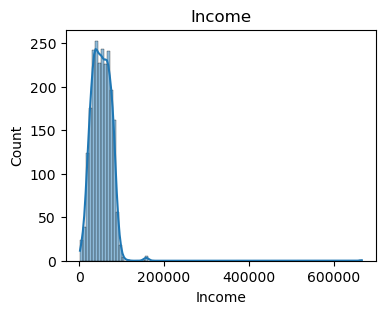

In [16]:
plt.figure(figsize=(4,3))
sns.histplot(df["Income"],kde=True)
plt.title("Income")
plt.show()

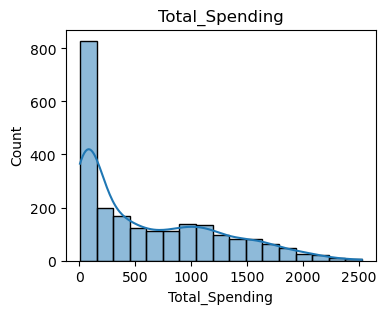

In [17]:
plt.figure(figsize=(4,3))
sns.histplot(df["Total_Spending"],kde=True)
plt.title("Total_Spending")
plt.show()

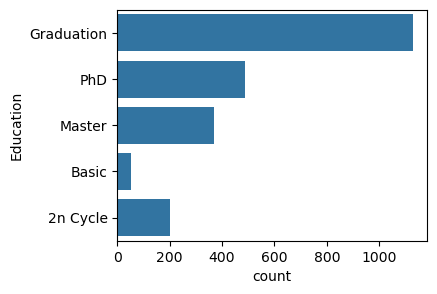

In [18]:
plt.figure(figsize=(4,3))
sns.countplot(y="Education",data=df)
plt.show()

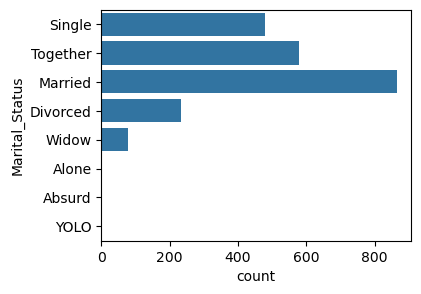

In [19]:
plt.figure(figsize=(4,3))
sns.countplot(y="Marital_Status",data=df)
plt.show()

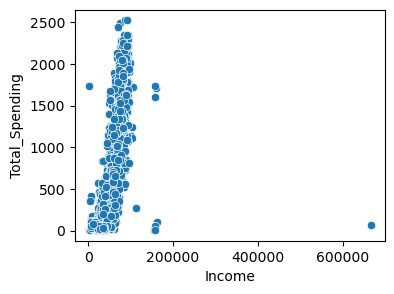

In [20]:
plt.figure(figsize=(4,3))
sns.scatterplot(x="Income",y="Total_Spending",data=df)
plt.show()

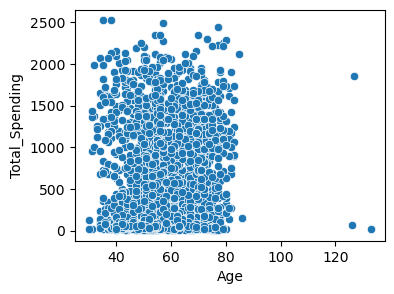

In [21]:
plt.figure(figsize=(4,3))
sns.scatterplot(x="Age",y="Total_Spending",data=df)
plt.show()

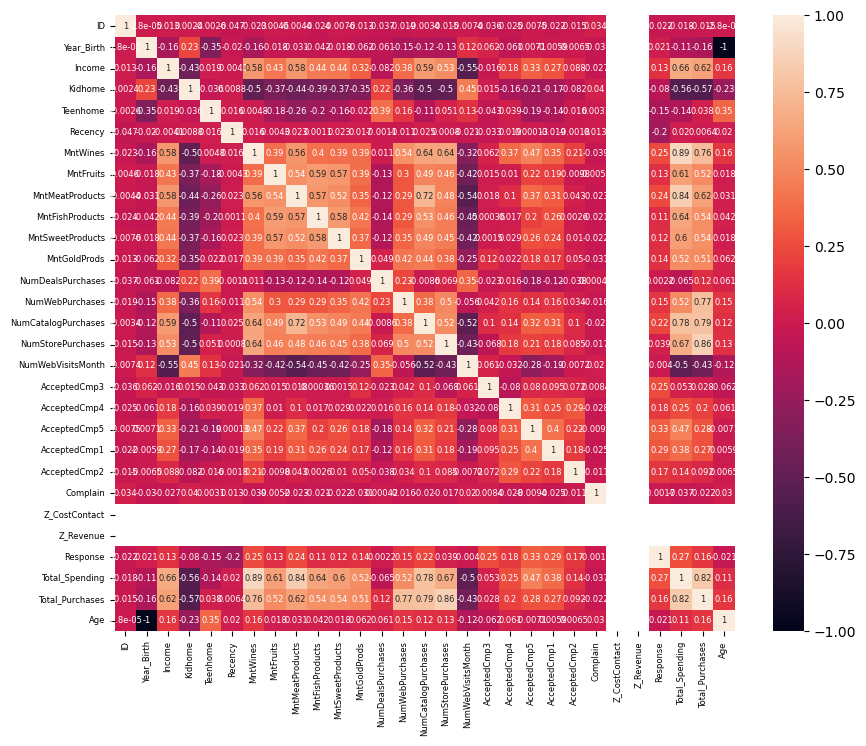

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,annot_kws = {"size" : 6})
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.show()

# K-Means Clustering 

In [23]:
#Customer segmentation ka objective customer value aur purchasing behavior ko identify karna tha.
#Income customer ki purchasing power batata hai, Total Spending uska actual expenditure batata hai aur
# Total Purchases buying frequency batati hai, Recency = Last purchase kitne din pehle hui, ye btata hai
#Ye 4 features customer behavior ko sabse achhi tarah represent karte hain, isliye maine clustering ke liye inhe select kiya.

In [24]:
X = df[["Income","Recency","Total_Spending","Total_Purchases"]]

In [25]:
# Scaling :-

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method 

In [26]:
# WCSS (Within Cluster Sum of Squares) batata hai :- Cluster ke andar data points apne centroid ke kitne paas hain.
# "WCSS jitna kam, clusters utne compact."
c = []
for i in range(1,11):
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(X_scaled)
    c.append(km.inertia_)

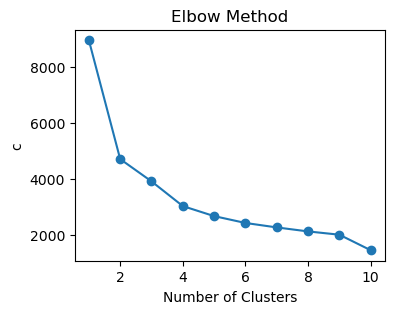

In [27]:
plt.figure(figsize=(4,3))
plt.plot(range(1,11),c,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("c")
plt.title("Elbow Method")

plt.show()

In [28]:
for k in [4,5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df["Cluster"] = kmeans.fit_predict(X_scaled)
    print(df["Cluster"].value_counts())

Cluster
0    621
1    615
3    547
2    457
Name: count, dtype: int64
Cluster
4    539
0    527
3    487
1    347
2    340
Name: count, dtype: int64


In [29]:
# Final KMeans model :-
kmeans = KMeans(n_clusters=5,random_state=42)
# Cluster labels generate kar rahe hain
df["Cluster"] = kmeans.fit_predict(X_scaled)

# n_clusters = 5 -->  5 customer groups banenge

# fit_predict() --> model train bhi karega......har customer ko cluster number bhi assign karega

In [30]:
# Har cluster me kitne customers hain

print(df["Cluster"].value_counts())

Cluster
4    539
0    527
3    487
1    347
2    340
Name: count, dtype: int64


In [31]:
# Har cluster ka average behavior dekh rahe hain
cluster_profile = df.groupby("Cluster")[[
        "Income",
        "Recency",
        "Total_Spending",
        "Total_Purchases"
    ]].mean().round(2)

cluster_profile

,Income,Recency,Total_Spending,Total_Purchases
Cluster,,,,
0,32608.62,25.76,80.46,5.42
1,56068.80,30.76,541.52,14.88
2,77056.48,23.38,1387.41,20.61
3,70570.42,74.74,1195.74,19.27
4,36744.81,76.82,134.76,6.81


In [32]:
# Cluster Persona---- profiling
# 0	Budget Customers
# 1	Regular Customers
# 2	Premium Customers
# 3	At-Risk High Value Customers
# 4	Lost Customers

# Cluster 2 ke customers ki average income, spending aur purchase frequency sabse zyada thi.
# Saath hi inhone recently purchase bhi kiya tha. Isliye inhe Premium Customers classify kiya gaya.

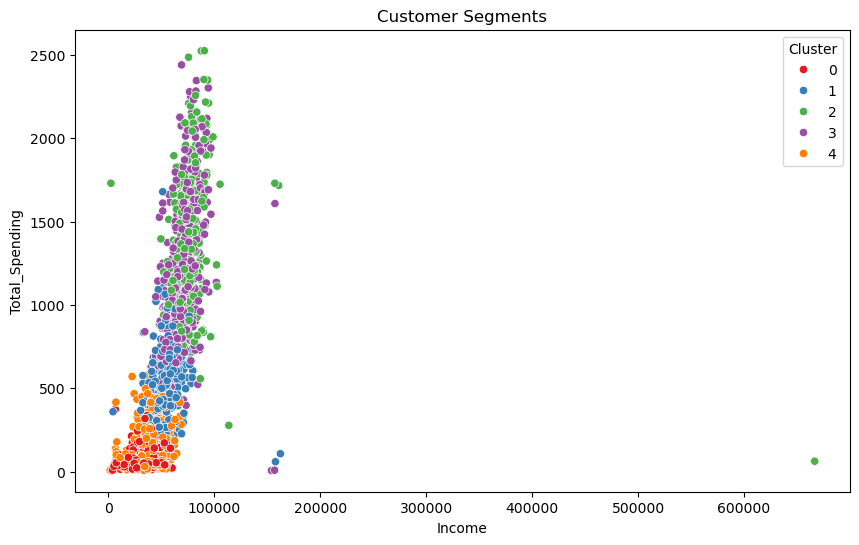

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="Set1")
plt.title("Customer Segments")
plt.show()

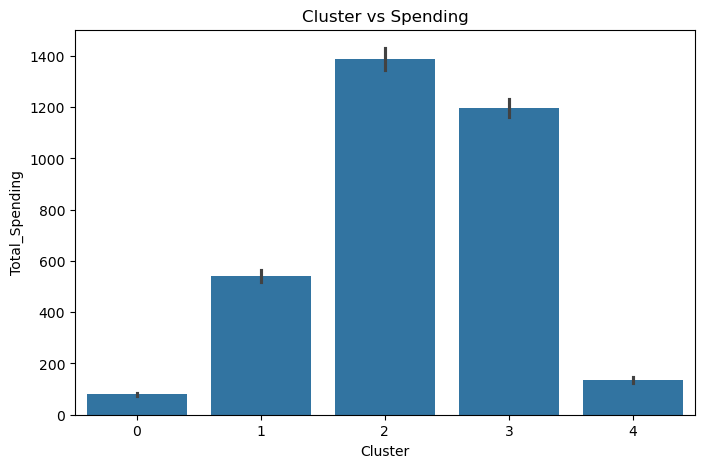

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Cluster",
    y="Total_Spending",
    data=df
)
plt.title("Cluster vs Spending")
plt.show()

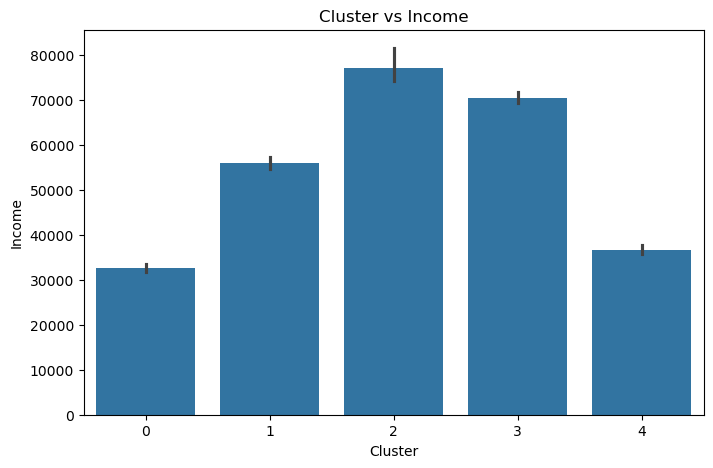

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Cluster",
    y="Income",
    data=df
)
plt.title("Cluster vs Income")
plt.show()

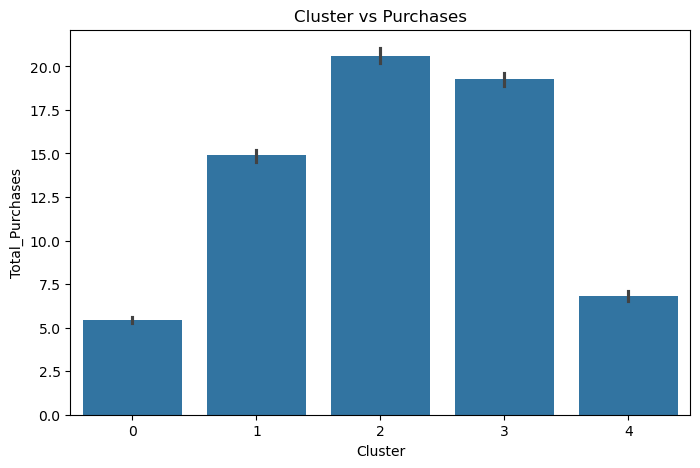

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Cluster",
    y="Total_Purchases",
    data=df
)
plt.title("Cluster vs Purchases")
plt.show()